In [1]:
import sys
sys.path.insert(0,'..')

import oqupy as oqupy
import numpy as np
import matplotlib.pyplot as plt


In [13]:
omega_cutoff = 5
alpha = 0.1
temperature = 5

def j(x):
    return 2*alpha*x

# compute the process tensor with the counting field value u=0.1

correlations=oqupy.bath_correlations.CountingCustomSD(j,cutoff=omega_cutoff,countingfield=0.1,
                                                 cutoff_type='exponential',temperature=temperature)



correlationsnocf=oqupy.bath_correlations.CountingCustomSD(j,cutoff=omega_cutoff,countingfield=0.0,
                                                 cutoff_type='exponential',temperature=temperature)


bath=oqupy.Bath(oqupy.operators.sigma("z")/2.0, correlations)
bathnocf=oqupy.Bath(oqupy.operators.sigma("z")/2.0, correlationsnocf)

pt_tempo_parameters = oqupy.TempoParameters(dt=0.1, dkmax=20, epsrel=10**(-4))

ptt=oqupy.pt_tempo.PtTempoCounting(bath,0.0,2.0,parameters=pt_tempo_parameters)
pttnocf=oqupy.pt_tempo.PtTempoCounting(bathnocf,0.0,2.0,parameters=pt_tempo_parameters)
ptt.compute()
pttnocf.compute()



--> PT-TEMPO computation:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.2s
--> PT-TEMPO computation:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.2s


In [14]:

initial_state=oqupy.operators.spin_dm("z-")

def hamiltonian_t(t): 
    return oqupy.operators.sigma("x")/2.0

# evaluate the dynamics at that counting field

system = oqupy.TimeDependentSystem(hamiltonian_t)

proctens=ptt.get_process_tensor()
proctensnocf=pttnocf.get_process_tensor()
dynamics = oqupy.compute_dynamics(system=system, initial_state=initial_state,process_tensor=proctens)
dynamicsnocf = oqupy.compute_dynamics(system=system, initial_state=initial_state,process_tensor=proctensnocf)


--> Compute dynamics:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.4s
--> Compute dynamics:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.4s


/Users/paul/OQuPy/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/paul/OQuPy/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


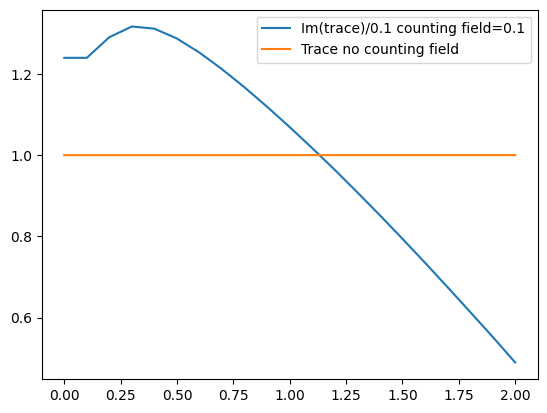

In [15]:
# this should be the mean heat transfer to/from the bath, evaluated at counting field 0.1
plt.plot(dynamics.times,dynamics.states.trace(axis1=1,axis2=2).imag/0.1,label='Im(trace)/0.1 counting field=0.1')
# trace of the density matrix when u=0.0 for comparison
plt.plot(dynamics.times,dynamicsnocf.states.trace(axis1=1,axis2=2),label='Trace no counting field')
plt.legend()

/Users/paul/OQuPy/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/paul/OQuPy/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


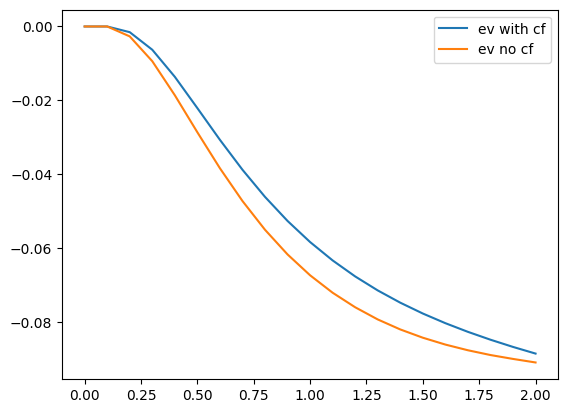

In [17]:
# look at expectation values, after running the above with u=0.0 and 0.1 
# (the u=0.1 case is not a real expectation value but just to see)

plt.plot(dynamics.times,list(map(lambda x: np.matmul(x,oqupy.operators.sigma("x")).trace(),dynamics.states)),label='ev with cf')

plt.plot(dynamics.times,list(map(lambda x: np.matmul(x,oqupy.operators.sigma("x")).trace(),dynamicsnocf.states)),label='ev no cf')

plt.legend()

In [5]:
# let's try the tempo version, first the normal dynamics
# the quantities bath and bathnocf are set up above

tsystem = tempo.System(0.5 * tempo.operators.sigma("x"))
tparas=tempo.TempoParameters(dt=0.1, dkmax=20, epsrel=10**(-4))
trun=tempo.Tempo(tsystem,bathnocf,parameters=pt_tempo_parameters,initial_state=initial_state,start_time=0.0)

In [6]:
dynamics=trun.compute(end_time=2.0)

100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.4s


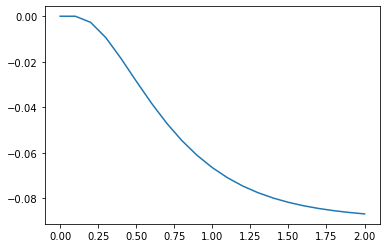

In [7]:
t, s_x = dynamics.expectations(tempo.operators.sigma("x"), real=True)

plt.plot(t, s_x, label=r'$\alpha=0.3$')

In [8]:
truncf=tempo.tempo.TempoCounting(tsystem,bath,parameters=pt_tempo_parameters,initial_state=initial_state,start_time=0.0)

In [9]:
dynamicscf=truncf.compute(end_time=2.0)

100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.3s


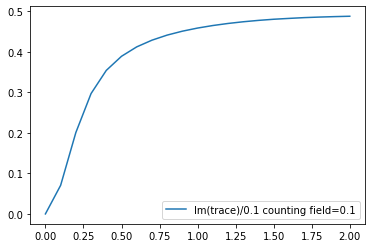

In [10]:
#  extract the heat from the tempo simulatio with u=0.1
plt.plot(dynamicscf.times,dynamicscf.states.trace(axis1=1,axis2=2).imag/0.1,label='Im(trace)/0.1 counting field=0.1')
plt.legend()

In [11]:
# however, let's look at the two sets of results - from tempo
dynamicscf.states.trace(axis1=1,axis2=2).imag


array([0.        , 0.00705024, 0.0200705 , 0.02968531, 0.03539501,
       0.03887345, 0.04119556, 0.04284412, 0.04409903, 0.04506575,
       0.04583638, 0.04645946, 0.04696862, 0.04738694, 0.04772719,
       0.04800744, 0.04821598, 0.04840729, 0.04854541, 0.04865653,
       0.04874887])

In [12]:
# and pttempo 
dynamics.states.trace(axis1=1,axis2=2).imag

array([ 0.00000000e+00,  0.00000000e+00, -5.71237903e-21,  2.17409068e-16,
        2.36602546e-16,  1.23912185e-16, -7.21681724e-16, -1.21941438e-15,
       -5.34120641e-16, -2.37884380e-17,  8.38586125e-16,  1.37866172e-15,
        1.65076052e-15,  8.92883053e-16, -3.73702474e-17,  2.74895196e-16,
        6.09598145e-16,  1.23380029e-15,  1.19393104e-15,  1.58127549e-15,
        2.82432348e-15])

In [65]:
process_tensor=ptt.get_process_tensor()
forwards,final,backwards=tempo.adjoint_method.compute_tensors_from_system(process_tensor=process_tensor,system=system,initial_state=tempo.operators.spin_dm("z-"),target_state=tempo.operators.sigma("id"))

In [14]:
final.trace() # this should be the final heat correct

(0.9692387911229812+0.04894559946300303j)

In [15]:
list(reversed(backwards[::2]))[0].shape

(4, 4)

In [16]:
import tensornetwork as tn
# now we stich them together to compute a set of correlation functions,
# here is the operator we want to insert - a copy, trace operator
# if I backpropagate 
copytrace=np.array([[1.,0.,0.,0.],[0.,0.,0.,0.],[0.,0.,0.,0.],[0.,0.,0.,1.]])
cflist=[]
fin=final.trace()
backlen=len(backwards)
for i in range(int(backlen/2)):
    forc=forwards[2*i]
    backc=backwards[backlen-1-2*i]
    addnode=tn.Node(copytrace)
    forc[0] ^ backc[0]
    forc[1] ^ addnode[0]
    backc[1] ^ addnode[1]
    result=forc @ backc @ addnode
    cflist.append((result.tensor+0.0))


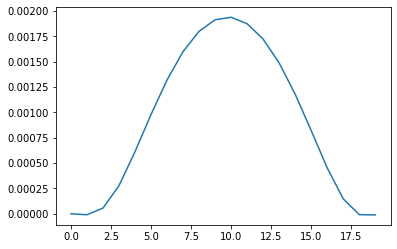

In [17]:
plt.plot(np.array(cflist).imag-fin.imag) # i used the identity operator so this should be one

In [18]:
ptt._backend_instance._sum_north_scaled

array([2., 2., 2., 2.])

In [19]:
np.matmul(np.identity(4),np.array([1,0,0,1]))

array([1., 0., 0., 1.])

In [20]:
np.outer(np.array([1,0,0,1]),np.identity(4))

array([[1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.]])

In [21]:
np.outer(tempo.spin)

(2, 2)

In [22]:
test=tempo.util.create_delta(np.array([[1,2],[3,4]]),index_scrambling=[0,1,1])

In [23]:
test

array([[[1, 0],
        [0, 2]],

       [[3, 0],
        [0, 4]]])

In [24]:
test=tempo.util.create_delta(np.identity(4),index_scrambling=[0,1,1])

In [25]:
np.matmul(test,np.array([1,0,0,1]))

array([[1., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 1.]])

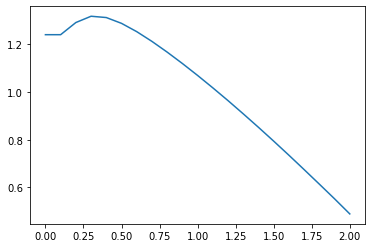

In [29]:
plt.plot(dynamics.times,dynamics.states.trace(axis1=1,axis2=2).imag/0.1,label='Im(trace)/0.1 counting field=0.1')

In [34]:
countfieldnormerror=dynamics.states.trace(axis1=1,axis2=2)
(countfieldnormerror.imag)/(countfieldnormerror.real)

array([0.14205413, 0.14205413, 0.1483792 , 0.15125   , 0.15004413,
       0.14649575, 0.14170867, 0.13623627, 0.13034892, 0.12420183,
       0.11786843, 0.11139939, 0.10483139, 0.09815793, 0.09144238,
       0.08466884, 0.07786238, 0.07101829, 0.06418256, 0.05738723,
       0.05049901])

In [39]:
countfieldnormerror.real

array([0.8722661 , 0.8722661 , 0.86935849, 0.8702526 , 0.87362017,
       0.87818513, 0.88338082, 0.88892895, 0.89469851, 0.90061421,
       0.90663504, 0.91273618, 0.91889952, 0.92508674, 0.93133008,
       0.9376134 , 0.9439208 , 0.95024575, 0.9565985 , 0.96295036,
       0.96923879])

In [41]:
process_tensor._trace_out

array([0.70710678+0.j, 0.        +0.j, 0.        +0.j, 0.70710678+0.j])

In [96]:
# let's use the adjoint method to calculate the heat current
# by adapting Don Gribben's approach
# if the coupling to the bath is s then the heat current at time t is
# int_0^t <s(t)s(t')> K(t,t') where K=2 int dw w J(w)cos(w(t-t'))

# oops I have discovered that this stiching together approach is wrong.


def corrfun(pt,system,initial_state,op1,op2,num_steps,nstepsback):
    """
    Evaluate the correlation function <s(t)s(t')> where s(t) is operator op1 and s(t') is op2
    t is the state nsteps1 forward in the process tensor, and we calculate for t' from 1 to nstepsback-1 
    before that.
    """
    # forward propagate to nsteps1 and backpropagate. note waste of time backpropagating by too many steps
    # but clean up later
    # note the fudge of conjugating the target, only beause adjoint_method does that for other reasons
    forwards,final,backwards=tempo.adjoint_method.compute_tensors_from_system(process_tensor=pt,system=system,initial_state=initial_state,target_state=op1,num_steps=num_steps)
    cflist=[]
    op2super=tempo.util.right_super(op2)
    backlen=len(backwards)
    for i in range(2,backlen,2):
        forc=forwards[i]
        backc=backwards[-i]
        addnode=tn.Node(op2super)
        forc[0] ^ backc[0]
        forc[1] ^ addnode[0]
        backc[1] ^ addnode[1]
        result=forc @ backc @ addnode
        cflist.append((result.tensor+0.0))
    return cflist,forwards,final,backwards
        

In [6]:
np.outer(tempo.operators.sigma("id"),tempo.operators.sigma("id"))

array([[1.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]])

In [8]:
tempo.util.right_super(tempo.operators.sigma("id"))

array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]])

In [97]:



import tensornetwork as tn
proctens=pttnocf.get_process_tensor()
finalstep=len(proctens)
cflist,forwards,final,backwards=corrfun(proctens,system=system,initial_state=tempo.operators.spin_dm("z-"),op1=tempo.operators.sigma("z")/2,
               op2=tempo.operators.sigma("z")/2,num_steps=len(proctens),nstepsback=100)


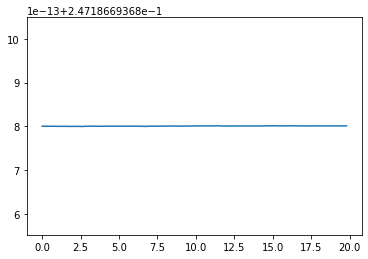

In [98]:
plt.plot(np.array(range(len(cflist)))*(proctens.dt),cflist)

In [95]:
final


array([[0.        +0.00000000e+00j, 0.        +0.00000000e+00j],
       [0.        +0.00000000e+00j, 0.98874677-3.34511463e-10j]])

In [58]:
proctens.get_mpo_tensor(19)

array([[[[-9.90513064e-04-2.30013718e-18j,
           0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j],
         [ 0.00000000e+00+0.00000000e+00j,
          -9.98170957e-03+1.20087137e-02j,
           0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j],
         [ 0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j,
           1.18551064e-02-1.20087137e-02j,
           0.00000000e+00+0.00000000e+00j],
         [ 0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j,
          -9.90513064e-04+6.23055911e-18j]]],


       [[[ 2.19775116e-04+3.29662675e-04j,
           0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j,
           0.00000000e+00+0.00000000e+00j],
         [ 0.00000000e+00+0.00000000e+00j,
          -4.03285769e-02-6.37032387e-03j,
           0.00000000e+00+0.00000000e+00j,
  

In [63]:
list(range(0,10,2))

[0, 2, 4, 6, 8]

In [72]:
list(range(0,len(backwards),2))[]

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38]